# La régularisation par cohérence, ou l'art d'être constant avec soi-même

On passe à la segmentation. Et pour ça, on va utiliser une des techniques les plus puissantes du SSL : la régularisation par cohérence. Le principe est d'une simplicité désarmante : un modèle doit donner des prédictions similaires pour la même image, même si celle-ci est vue sous différents angles (augmentations).

Si vous reconnaissez votre chat qu'il soit à l'endroit, à l'envers ou un peu flou, votre modèle devrait en faire autant !

On va implémenter une architecture populaire qui utilise cette idée : le Mean Teacher (le prof moyen). Un modèle 'étudiant' apprend normalement, tandis qu'un modèle 'professeur' (plus stable) le guide. Le professeur n'est que la moyenne des poids passés de l'étudiant.

Objectifs du jour :

- Changer de tâche : passer à la segmentation sur le dataset Kvasir-SEG.
- Mettre en place des pipelines d'augmentations faibles et fortes.
- Implémenter le modèle Mean Teacher.
- Calculer une perte de supervision (sur les données étiquetées) et une perte de cohérence (sur les non étiquetées).
- Visualiser les performances via l'évolution des pertes et le Dice Score.

On va utiliser seulement 50 images étiquetées pour simuler un scénario réaliste où les masques de segmentation sont rares. Prêts pour la démo ?

## 1. Préparation pour la segmentation
On importe les bibliothèques nécessaires pour la segmentation, notamment des fonctions de perte comme ***le CrossEntropyLoss (adapté pour la segmentation multiclasse)*** et la librairie d'augmentation ***albumentations*** pour créer des transformations faibles et fortes.

In [1]:
import os                        # Interagir avec le système de fichiers (chemins, dossiers, etc.)
import numpy as np               # Calcul scientifique et manipulation de tableaux numériques
import matplotlib.pyplot as plt  # Visualisation (images, courbes, métriques)

import torch                     # Base de PyTorch : tenseurs, GPU, opérations mathématiques
import torch.nn as nn            # Définition des couches de réseaux neuronaux
import torch.nn.functional as F  # Fonctions d'activation et de loss (ReLU, Softmax, CrossEntropy, etc.)

from torch.utils.data import (
    Dataset, DataLoader, Subset, random_split
)                                # Gestion des datasets et des DataLoaders

from tqdm import tqdm            # Affichage d’une barre de progression pour suivre les boucles d'entraînement

import albumentations as A       # Bibliothèque avancée d'augmentation d'images
from albumentations.pytorch import ToTensorV2  # Conversion NumPy → tensor PyTorch après augmentation

from PIL import Image            # Ouverture et manipulation des images (format PIL)


## Chargement du dataset
On utilise Kvasir-SEG, un dataset de segmentation de polypes du colon. On sélectionne 50 images étiquetées pour simuler un scénario semi-supervisé réaliste, où les masques sont coûteux à obtenir.

In [2]:
# Custom Dataset class for Kvasir-SEG
class KvasirSegDataset(Dataset):  # On crée un Dataset personnalisé en héritant de Dataset
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir        # Chemin du dossier contenant /images et /masks
        self.transform = transform      # Transformations d'augmentation (Albumentations)

        self.image_dir = os.path.join(data_dir, 'images')  # Dossier des images
        self.mask_dir = os.path.join(data_dir, 'masks')    # Dossier des masques

        # Liste triée des fichiers .jpg dans chaque dossier
        self.image_files = sorted([f for f in os.listdir(self.image_dir) if f.endswith('.jpg')])
        self.mask_files = sorted([f for f in os.listdir(self.mask_dir) if f.endswith('.jpg')])

        # Vérification : même nombre d'images et de masques
        assert len(self.image_files) == len(self.mask_files), "Mismatch between images and masks"

        # Vérification : le nom des images correspond au nom des masques (1-to-1)
        for img_f, mask_f in zip(self.image_files, self.mask_files):
            assert img_f == mask_f, f"Mismatch: {img_f} != {mask_f}"

    def __len__(self):
        return len(self.image_files)   # Retourne le nombre total d'images

    def __getitem__(self, idx):
        # Chemin de l'image et du masque correspondant
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        # Chargement de l'image en RGB → tableau NumPy (H, W, 3)
        image = np.array(Image.open(img_path).convert('RGB'))

        # Chargement du masque en niveaux de gris → tableau NumPy (H, W)
        mask = np.array(Image.open(mask_path).convert('L'))

        # Binarisation du masque : 0 = fond, 1 = polype
        mask = (mask > 0).astype(np.uint8)

        # Application des augmentations si elles existent
        if self.transform:
            augmented = self.transform(image=image, mask=mask)  # Transformation simultanée image + masque
            image = augmented['image']                           # Image transformée → Tensor
            mask = augmented['mask']                             # Masque transformé → Tensor

        return image, mask   # On retourne l'image et le masque prêts pour l'entraînement


On définit deux niveaux d'augmentation :

- Faible (weak) : pour le teacher, avec des transformations légères comme des flips horizontaux.
- Forte (strong) : pour le student, avec des transformations plus agressives (rotation, flou, cutout) pour le pousser à généraliser.
Un dataset custom gère ces deux pipelines : les données étiquetées reçoivent des augmentations fortes, les non étiquetées reçoivent les deux types.

In [3]:
# Augmentation pipelines with resize
IMG_SIZE = (384, 384)  # Fixed size for Kvasir-SEG
weak_transform = A.Compose([
    A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1], interpolation=1),  # Resize to 384x384
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # RGB normalization
    ToTensorV2()
])

strong_transform = A.Compose([
    A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1], interpolation=1),  # Resize to 384x384
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussianBlur(p=0.3),
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(height=IMG_SIZE[0], width=IMG_SIZE[1], interpolation=1),  # Resize to 384x384
    A.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # RGB normalization
    ToTensorV2()
])

# Adapted MeanTeacherDataset for Kvasir-SEG
class MeanTeacherDataset(Dataset):
    def __init__(self, dataset, indices, weak_transform, strong_transform, is_labeled=True):
        self.dataset = torch.utils.data.Subset(dataset, indices)
        self.weak_transform = weak_transform
        self.strong_transform = strong_transform
        self.is_labeled = is_labeled

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, mask = self.dataset[idx]
        img = np.asarray(img, dtype=np.uint8)  # Shape: (H, W, 3) or (3, H, W) if tensor
        mask = np.asarray(mask, dtype=np.uint8)  # Shape: (H, W) or (1, H, W) if tensor

        # Ensure mask is binary (0 or 1)
        mask = (mask > 0).astype(np.uint8)

        # Check and reshape image to (H, W, 3)
        if isinstance(img, np.ndarray) and len(img.shape) == 3:
            if img.shape[0] == 3:  # Tensor-like (3, H, W)
                img = np.transpose(img, (1, 2, 0))  # Convert to (H, W, 3)
            elif img.shape[2] != 3:  # Invalid channels
                raise ValueError(f"Image at index {idx} has invalid shape {img.shape}, expected (H, W, 3)")
        else:
            raise ValueError(f"Image at index {idx} has invalid shape {img.shape}, expected (H, W, 3)")

        # Check and reshape mask to (H, W)
        if isinstance(mask, np.ndarray):
            if len(mask.shape) == 3:
                if mask.shape[0] == 1:  # Tensor-like (1, H, W)
                    mask = mask.squeeze(0)  # Convert to (H, W)
                elif mask.shape[2] == 1:  # (H, W, 1)
                    mask = mask.squeeze(2)  # Convert to (H, W)
                else:
                    raise ValueError(f"Mask at index {idx} has invalid shape {mask.shape}, expected (H, W)")
            elif len(mask.shape) != 2:
                raise ValueError(f"Mask at index {idx} has invalid shape {mask.shape}, expected (H, W)")

        # Ensure image and mask have the same H, W
        if img.shape[:2] != mask.shape[:2]:
            img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]), interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, (IMG_SIZE[1], IMG_SIZE[0]), interpolation=cv2.INTER_NEAREST)

        # Apply augmentations
        if not self.is_labeled:
            transformed_weak = self.weak_transform(image=img, mask=mask)
            transformed_strong = self.strong_transform(image=img, mask=mask)
            return transformed_weak['image'], transformed_strong['image']
        else:
            transformed = self.strong_transform(image=img, mask=mask)
            return transformed['image'], transformed['mask'].long()

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
# Configuration du dataset
import os

# Create directory for datasets if it doesn't exist
!mkdir -p /content/Kvasir-SEG  # Changed directory name to match expected unzipped folder

# Download the dataset if not already present
if not os.path.exists('/content/Kvasir-SEG/images'): # Updated path for existence check
    print("Downloading Kvasir-SEG dataset...")
    !wget -nc --no-check-certificate https://datasets.simula.no/downloads/kvasir-seg.zip -P /content/
    !unzip -q /content/kvasir-seg.zip -d /content/
    print("Kvasir-SEG dataset downloaded and extracted.")

data_dir = '/content/Kvasir-SEG'  # Update with the correct dataset path after extraction (changed to Kvasir-SEG)
dataset = KvasirSegDataset(data_dir=data_dir, transform=None)  # No transform initially

# Split for SSL demo: 50 labeled, 100 test, rest unlabeled
train_size = len(dataset)
labeled_size = 50
test_size = 100
unlabeled_size = train_size - labeled_size - test_size
labeled_dataset, test_dataset, unlabeled_dataset = random_split(dataset, [labeled_size, test_size, unlabeled_size])

# Assign transform to test_dataset
test_dataset.dataset.transform = test_transform

# DataLoaders for MeanTeacherDataset
labeled_train_dataset = MeanTeacherDataset(dataset, labeled_dataset.indices, weak_transform, strong_transform, is_labeled=True)
unlabeled_train_dataset = MeanTeacherDataset(dataset, unlabeled_dataset.indices, weak_transform, strong_transform, is_labeled=False)

labeled_loader = DataLoader(labeled_train_dataset, batch_size=4, shuffle=True)
unlabeled_loader = DataLoader(unlabeled_train_dataset, batch_size=16, shuffle=True)

# Print number of labeled, unlabeled, and test samples
print(f"Dataset loaded: {len(dataset)} samples | Labeled: {len(labeled_dataset)} | Unlabeled: {len(unlabeled_dataset)} | Test: {len(test_dataset)}")

Dataset loaded: 1000 samples | Labeled: 50 | Unlabeled: 850 | Test: 100


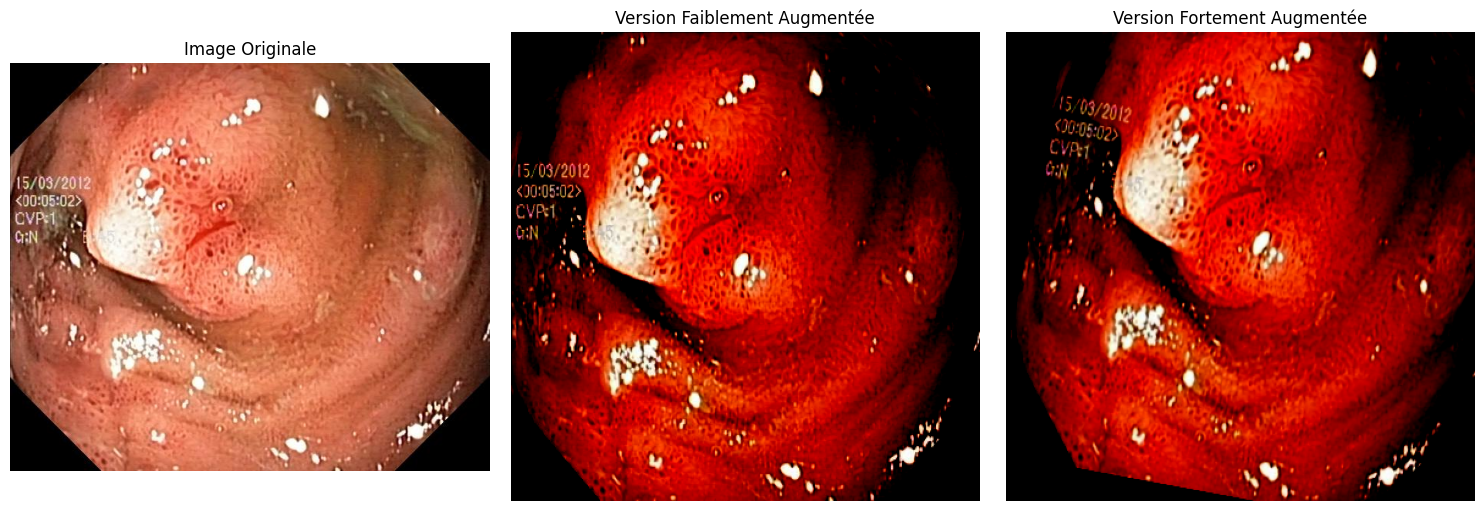

In [9]:
# Charger une image d'exemple
example_idx = 0
example_image = Image.open(os.path.join(dataset.image_dir, dataset.image_files[example_idx])).convert('RGB')
example_mask = Image.open(os.path.join(dataset.mask_dir, dataset.mask_files[example_idx])).convert('RGB')

# Appliquer les augmentations
weak_image = weak_transform(image=np.array(example_image))['image']
strong_image = strong_transform(image=np.array(example_image))['image']

# Visualiser
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(example_image)
axes[0].set_title('Image Originale')
axes[0].axis('off')
axes[1].imshow(weak_image.permute(1, 2, 0))
axes[1].set_title('Version Faiblement Augmentée')
axes[1].axis('off')
axes[2].imshow(strong_image.permute(1, 2, 0))
axes[2].set_title('Version Fortement Augmentée')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## 2. Le modèle (student & teacher)
Pour la segmentation, on utilise une architecture de type U-Net simplifiée (pour la démo). On crée deux instances : student et teacher. Le teacher est une copie du student, mais ses poids sont mis à jour via une moyenne mobile exponentielle (EMA) pour plus de stabilité.

In [13]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Un U-Net très simple pour l'exemple
def simple_unet(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(inplace=True),
        nn.Conv2d(16, out_channels, 1)
    )

def create_models(in_channels, out_channels):
    student = simple_unet(in_channels, out_channels).to(device)
    teacher = simple_unet(in_channels, out_channels).to(device)

    # Le teacher ne s'entraîne pas par backprop, on gèle ses poids
    for param in teacher.parameters():
        param.detach_()

    return student, teacher

# Création des modèles
in_channels = 3  # RGB images for Kvasir-SEG
out_channels = 2  # Binary segmentation (polyp vs. background)
student_model, teacher_model = create_models(in_channels, out_channels)
print('Modèles Student et Teacher prêts pour la démo !')


Using device: cpu
Modèles Student et Teacher prêts pour la démo !


## 3. La boucle d'entraînement Mean Teacher

À chaque époque :
1. Le student est entraîné sur les données étiquetées avec une perte supervisée (CrossEntropyLoss).
2. Les données non étiquetées passent par le teacher (augmentations faibles) et le student (augmentations fortes), et on calcule une perte de cohérence (MSE) entre leurs prédictions softmax.
3. La perte totale combine la perte supervisée et la perte de cohérence.
4. Le teacher est mis à jour via une moyenne mobile exponentielle (EMA) des poids du student.

On affiche les pertes à chaque époque et on trace leur évolution pour voir la progression.

Entraînement Mean Teacher:  20%|██        | 1/5 [02:42<10:51, 162.96s/it]

Époque 1/5 - Perte Sup moyenne: 0.5494, Perte Con moyenne: 0.0318


Entraînement Mean Teacher:  40%|████      | 2/5 [05:02<07:27, 149.24s/it]

Époque 2/5 - Perte Sup moyenne: 0.4248, Perte Con moyenne: 0.0661


Entraînement Mean Teacher:  60%|██████    | 3/5 [07:19<04:47, 143.55s/it]

Époque 3/5 - Perte Sup moyenne: 0.4122, Perte Con moyenne: 0.0662


Entraînement Mean Teacher:  80%|████████  | 4/5 [09:37<02:21, 141.48s/it]

Époque 4/5 - Perte Sup moyenne: 0.4036, Perte Con moyenne: 0.0764


Entraînement Mean Teacher: 100%|██████████| 5/5 [12:12<00:00, 146.59s/it]

Époque 5/5 - Perte Sup moyenne: 0.4284, Perte Con moyenne: 0.0379


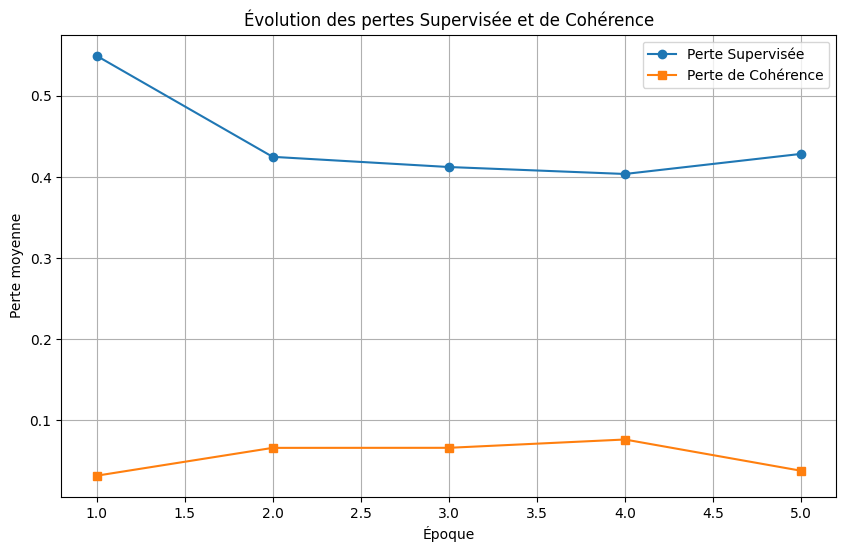

In [14]:
# Fonction pour mettre à jour le teacher via EMA
def update_teacher_model(student, teacher, alpha=0.99):
    """Mise à jour des poids du teacher par EMA : teacher = alpha * teacher + (1 - alpha) * student."""
    for teacher_param, student_param in zip(teacher.parameters(), student.parameters()):
        teacher_param.data.mul_(alpha)                              # teacher_param.data = alpha * teacher_param.data (multiplication in-place)
        teacher_param.data.add_((1 - alpha) * student_param.data)   # teacher_param.data += (1-alpha) * student_param.data (addition in-place)
        # Remarque : on utilise .data pour éviter que ces opérations soient tracées par autograd.
        # Optionnellement on peut entourer le bloc d'un `with torch.no_grad():` pour plus de sécurité.

# Pertes
supervised_criterion = nn.CrossEntropyLoss()  # Critère supervisé pour classification multi-classes (logits -> label integer)
consistency_criterion = nn.MSELoss()          # Critère de cohérence (MSE) entre distributions/probabilités student vs teacher

# Optimiseur
optimizer = torch.optim.Adam(student_model.parameters(), lr=0.001)  # Adam optimise les paramètres du student

# Paramètres d'entraînement
EPOCHS = 5                        # Nombre d'époques d'entraînement
consistency_weight = 0.1          # Poids appliqué à la perte de cohérence dans la perte totale

# Listes pour stocker les pertes par époque
epoch_sup_losses = []             # Liste pour stocker la perte supervisée moyenne par époque
epoch_con_losses = []             # Liste pour stocker la perte de cohérence moyenne par époque

# Boucle principale d'entraînement avec barre de progression
for epoch in tqdm(range(EPOCHS), desc='Entraînement Mean Teacher'):
    student_model.train()         # Met le student en mode entraînement (dropout, batchnorm en mode train)
    teacher_model.eval()          # Met le teacher en mode évaluation (pas de dropout, batchnorm en mode eval)
                                  # (On ne fait pas de backprop sur le teacher)
    sup_losses = []               # Liste temporaire pour les pertes supervisées du batch courant
    con_losses = []               # Liste temporaire pour les pertes de cohérence du batch courant

    # Itérer sur les deux loaders
    labeled_iter = iter(labeled_loader)    # Itérateur sur les batches étiquetés
    unlabeled_iter = iter(unlabeled_loader) # Itérateur sur les batches non-étiquetés
    num_batches = min(len(labeled_loader), len(unlabeled_loader))  # Nombre d'itérations = taille du plus petit loader

    for _ in range(num_batches):
        # Récupération d'un batch étiqueté (avec protection StopIteration)
        try:
            labeled_imgs, masks = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(labeled_loader)   # si itérateur épuisé, le réinitialiser
            labeled_imgs, masks = next(labeled_iter)

        # Récupération d'un batch non-étiqueté composé de versions weak & strong (augmentation faible/forte)
        try:
            weak_unlabeled, strong_unlabeled = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader) # réinitialisation si nécessaire
            weak_unlabeled, strong_unlabeled = next(unlabeled_iter)

        # Envoyer les tenseurs sur le device (CPU/GPU)
        labeled_imgs, masks = labeled_imgs.to(device), masks.to(device)
        weak_unlabeled, strong_unlabeled = weak_unlabeled.to(device), strong_unlabeled.to(device)

        optimizer.zero_grad()       # Remise à zéro des gradients (important avant backward)

        # 1. Perte supervisée (sur les données étiquetées)
        pred_labeled = student_model(labeled_imgs)             # Forward pass du student sur les images étiquetées
        loss_sup = supervised_criterion(pred_labeled, masks)   # Calcul de la CrossEntropy entre logits et labels

        # 2. Perte de cohérence (entre student et teacher sur données non-étiquetées)
        with torch.no_grad():                                  # Pas de gradient pour le teacher (inference seulement)
            teacher_preds = teacher_model(weak_unlabeled)      # Teacher prédit sur version "weak" (augmentation faible)
        student_preds = student_model(strong_unlabeled)       # Student prédit sur version "strong" (augmentation forte)

        # Calculer la perte de cohérence sur les probabilités (softmax)
        loss_con = consistency_criterion(
            F.softmax(student_preds, dim=1),                  # Probabilités prédite par le student
            F.softmax(teacher_preds, dim=1)                   # Probabilités prédite par le teacher (sans grad)
        )

        # 3. Perte totale combinant supervision + cohérence pondérée
        total_loss = loss_sup + consistency_weight * loss_con

        total_loss.backward()        # Backpropagation : calcule les gradients pour le student
        optimizer.step()             # Mise à jour des paramètres du student via l'optimiseur

        # 4. Mise à jour du teacher via EMA (Exponential Moving Average)
        update_teacher_model(student_model, teacher_model)    # Met à jour les poids du teacher en utilisant les poids du student

        # Stocker les pertes (pour tracking)
        sup_losses.append(loss_sup.item())   # .item() pour convertir le tenseur scalaire en float
        con_losses.append(loss_con.item())

    # Calculer et stocker les pertes moyennes par époque (après tous les batches)
    epoch_sup_losses.append(np.mean(sup_losses))
    epoch_con_losses.append(np.mean(con_losses))

    # Affichage facultatif par époque (ici on affiche la dernière moyenne calculée)
    print(f'Époque {epoch+1}/{EPOCHS} - Perte Sup moyenne: {np.mean(sup_losses):.4f}, Perte Con moyenne: {np.mean(con_losses):.4f}')

# Après toutes les époques : afficher l'évolution des pertes
plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), epoch_sup_losses, label='Perte Supervisée', marker='o')  # Courbe perte supervisée
plt.plot(range(1, EPOCHS + 1), epoch_con_losses, label='Perte de Cohérence', marker='s') # Courbe perte cohérence
plt.xlabel('Époque')
plt.ylabel('Perte moyenne')
plt.title('Évolution des pertes Supervisée et de Cohérence')
plt.legend()
plt.grid(True)
plt.show()


## 4. Évaluation
On évalue le teacher_model (plus stable grâce à l'EMA) sur le jeu de test avec le Dice Score, une métrique clé en segmentation. On s'attend à ce que la régularisation par cohérence améliore les performances par rapport à un modèle entraîné uniquement sur les 20 images étiquetées.

In [15]:
# Fonction pour calculer le Dice score (adapted for binary segmentation)
def dice_score(pred, target, smooth=1e-8):
    pred = F.softmax(pred, dim=1)[:, 1, :, :]  # Probability for polyp class (1)
    target = target.float()  # Binary mask (0 or 1)
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# Evaluation on test set
teacher_model.eval()
total_dice = 0
test_loader_eval = DataLoader(test_dataset, batch_size=32, shuffle=False)

with torch.no_grad():
    for images, masks in test_loader_eval:
        images, masks = images.to(device), masks.to(device)
        outputs = teacher_model(images)
        total_dice += dice_score(outputs, masks).item()

avg_dice = total_dice / len(test_loader_eval)
print(f'Dice Score moyen sur le jeu de test : {avg_dice:.3f}')

Dice Score moyen sur le jeu de test : 0.183


## 5. Visualisation des prédictions
Pour mieux comprendre les performances, visualisons quelques prédictions du teacher_model sur le jeu de test, avec les images, les masques ground truth, et les masques prédits.

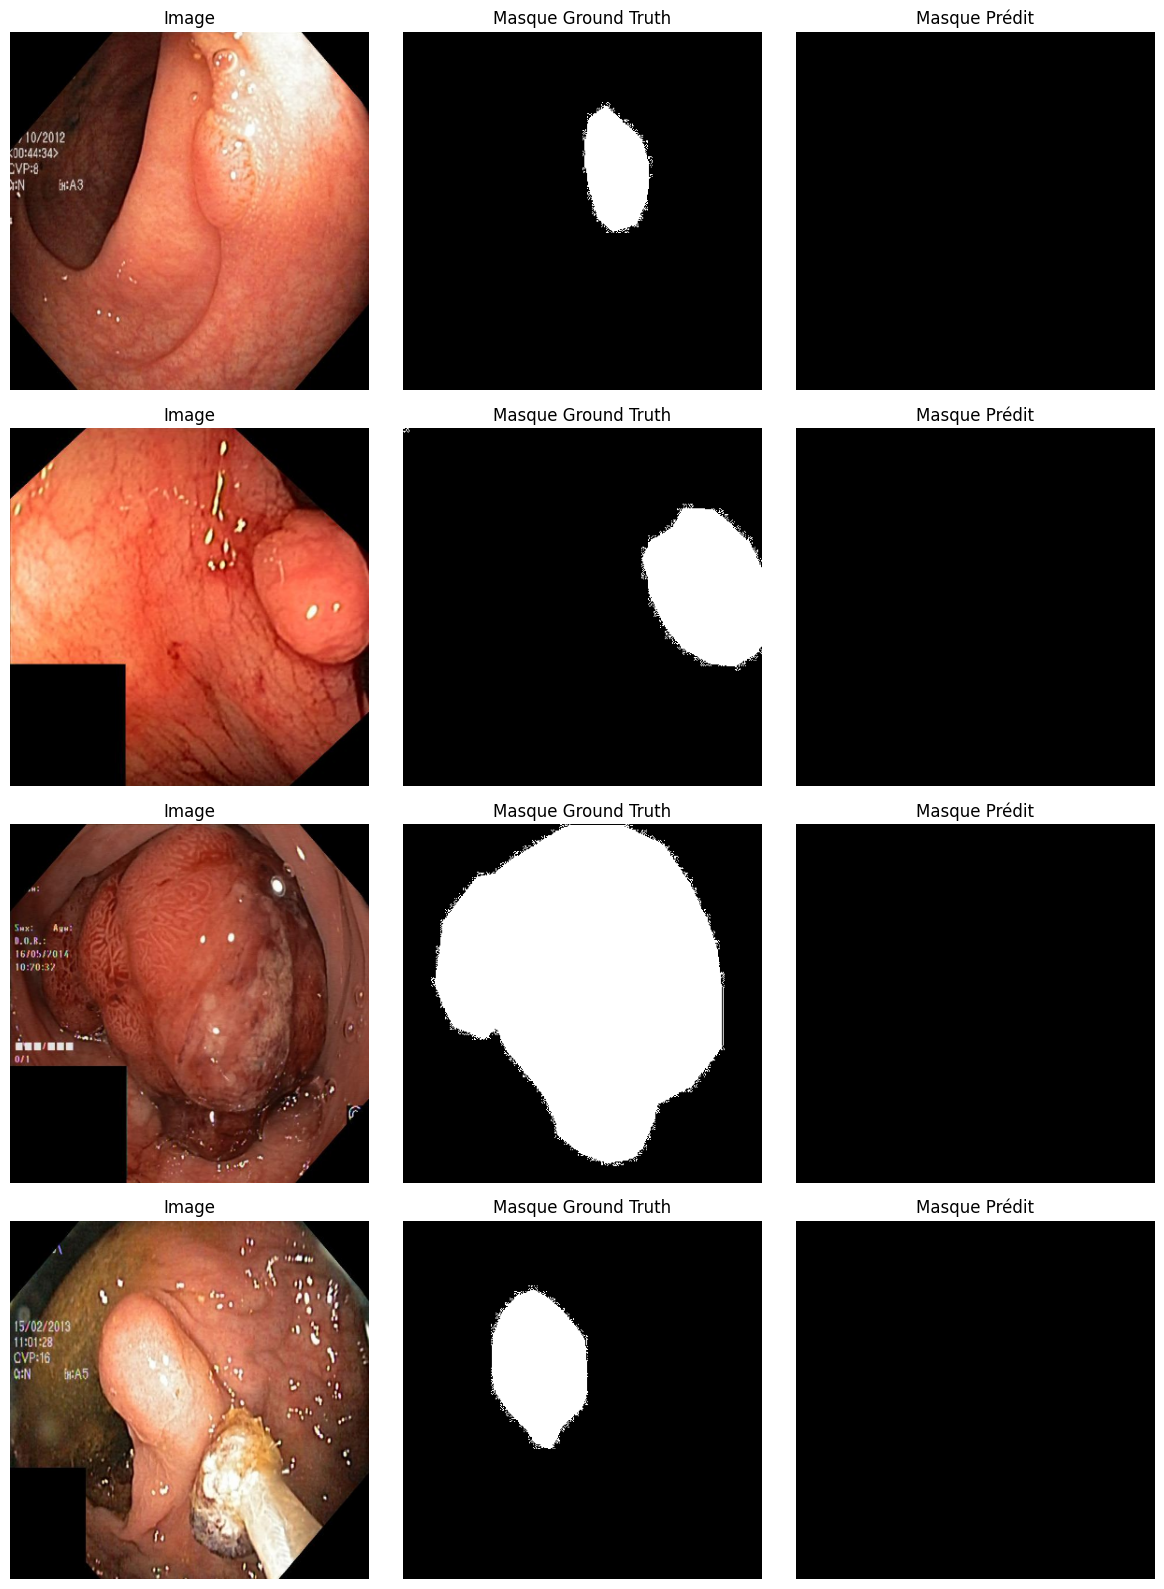

In [16]:
# Visualiser quelques prédictions
num_examples = 4
test_subset = Subset(test_dataset, range(num_examples))
test_loader_viz = DataLoader(test_subset, batch_size=num_examples, shuffle=False)

teacher_model.eval()
with torch.no_grad():
    images, masks = next(iter(test_loader_viz))
    images, masks = images.to(device), masks.to(device)
    outputs = teacher_model(images)
    preds = F.softmax(outputs, dim=1).argmax(dim=1).cpu().numpy()
    images = images.cpu().permute(0, 2, 3, 1).numpy() * 0.5 + 0.5  # Denormalize RGB
    masks = masks.cpu().numpy()

fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))
for i in range(num_examples):
    axes[i, 0].imshow(images[i])
    axes[i, 0].set_title('Image')
    axes[i, 0].axis('off')
    axes[i, 1].imshow(masks[i], cmap='gray')
    axes[i, 1].set_title('Masque Ground Truth')
    axes[i, 1].axis('off')
    axes[i, 2].imshow(preds[i], cmap='gray')
    axes[i, 2].set_title('Masque Prédit')
    axes[i, 2].axis('off')
plt.tight_layout()
plt.show()

On va augmenter le nombre d'époch à 10 et on varie un consistency_weight qui augmente progressivement (ex: de 0 à 0.1 sur 10 époques).
 voici les différentes étapes a implémenter pour voir comment le modéle reagir:

✔ Augmentation faible : rotation ±15°, contraste ±15%

✔ Augmentation forte : bruit gaussien + déformation élastique

✔ Poids de cohérence ajustable

✔ Époques augmentées à 10

✔ Intégration propre dans le pipeline Mean Teacher

/tmp/ipython-input-1587473782.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
/tmp/ipython-input-1587473782.py:16: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=50, sigma=10, alpha_affine=10, p=1.0),
Entraînement Mean Teacher:  10%|█         | 1/10 [02:17<20:36, 137.43s/it]

Époque 1/10 | Poids cohérence=0.0000 | Sup=0.4281 | Con=0.0445


Entraînement Mean Teacher:  20%|██        | 2/10 [04:36<18:27, 138.50s/it]

Époque 2/10 | Poids cohérence=0.0111 | Sup=0.4112 | Con=0.0297


Entraînement Mean Teacher:  30%|███       | 3/10 [06:59<16:21, 140.28s/it]

...

Époque 8/10 | Poids cohérence=0.0778 | Sup=0.4054 | Con=0.0149


Entraînement Mean Teacher:  90%|█████████ | 9/10 [20:41<02:16, 136.37s/it]

Époque 9/10 | Poids cohérence=0.0889 | Sup=0.4041 | Con=0.0171


Entraînement Mean Teacher: 100%|██████████| 10/10 [22:53<00:00, 137.33s/it]

Époque 10/10 | Poids cohérence=0.1000 | Sup=0.4322 | Con=0.0232


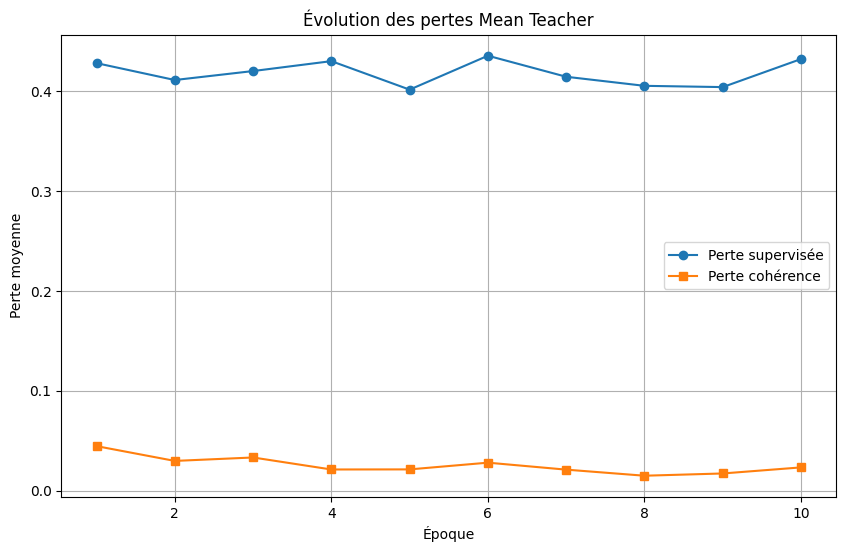

In [17]:
###############################################
#          AUGMENTATIONS FAIBLE / FORTE
###############################################

# Augmentation faible : rotation ±15°, contraste ±15%
weak_transform = A.Compose([
    A.Rotate(limit=15, p=1.0),
    A.RandomBrightnessContrast(brightness_limit=0.0,
                               contrast_limit=0.15, p=1.0),
    ToTensorV2()
])

# Augmentation forte : bruit gaussien + déformation élastique
strong_transform = A.Compose([
    A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
    A.ElasticTransform(alpha=50, sigma=10, alpha_affine=10, p=1.0),
    ToTensorV2()
])


###############################################
#     DATASET NON ÉTIQUETÉ AVEC AUGMENTATION
###############################################

class UnlabeledDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))

        weak_img = weak_transform(image=image)["image"]
        strong_img = strong_transform(image=image)["image"]

        return weak_img, strong_img


###############################################
#              FONCTION EMA TEACHER
###############################################

def update_teacher_model(student, teacher, alpha=0.99):
    """
    Mise à jour EMA (Exponential Moving Average) :
    teacher = alpha * teacher + (1 - alpha) * student
    """
    for teacher_param, student_param in zip(teacher.parameters(), student.parameters()):
        teacher_param.data.mul_(alpha)
        teacher_param.data.add_((1 - alpha) * student_param.data)


###############################################
#     CRITÈRES DE PERTE + OPTIMISEUR
###############################################

supervised_criterion = nn.CrossEntropyLoss()
consistency_criterion = nn.MSELoss()
optimizer = torch.optim.Adam(student_model.parameters(), lr=0.001)


###############################################
#       PARAMÈTRES D'ENTRAÎNEMENT
###############################################

EPOCHS = 10
max_consistency_weight = 0.1   # Poids max après dernière époque

def get_consistency_weight(epoch, max_epochs, max_weight):
    """
    Augmentation linéaire du poids de cohérence :
    0 → max_weight
    """
    return (epoch / (max_epochs - 1)) * max_weight


###############################################
#     LISTES POUR SUIVRE LES PERTES
###############################################

epoch_sup_losses = []
epoch_con_losses = []


###############################################
#            BOUCLE D'ENTRAÎNEMENT
###############################################

for epoch in tqdm(range(EPOCHS), desc="Entraînement Mean Teacher"):
    student_model.train()
    teacher_model.eval()

    # Poids progressif pour cette époque
    consistency_weight = get_consistency_weight(epoch, EPOCHS, max_consistency_weight)

    sup_losses = []
    con_losses = []

    labeled_iter = iter(labeled_loader)
    unlabeled_iter = iter(unlabeled_loader)

    num_batches = min(len(labeled_loader), len(unlabeled_loader))

    for _ in range(num_batches):

        # ---- Batch étiqueté ----
        try:
            labeled_imgs, masks = next(labeled_iter)
        except StopIteration:
            labeled_iter = iter(labeled_loader)
            labeled_imgs, masks = next(labeled_iter)

        # ---- Batch non étiqueté (faible + fort) ----
        try:
            weak_unlabeled, strong_unlabeled = next(unlabeled_iter)
        except StopIteration:
            unlabeled_iter = iter(unlabeled_loader)
            weak_unlabeled, strong_unlabeled = next(unlabeled_iter)

        # Envoi sur GPU
        labeled_imgs = labeled_imgs.to(device)
        masks = masks.to(device)
        weak_unlabeled = weak_unlabeled.to(device)
        strong_unlabeled = strong_unlabeled.to(device)

        optimizer.zero_grad()

        # ----------------------------
        #      1. Perte supervisée
        # ----------------------------
        pred_labeled = student_model(labeled_imgs)
        loss_sup = supervised_criterion(pred_labeled, masks)

        # ----------------------------
        #      2. Perte cohérente
        # ----------------------------
        with torch.no_grad():
            teacher_preds = teacher_model(weak_unlabeled)

        student_preds = student_model(strong_unlabeled)

        # Probabilités softmax
        loss_con = consistency_criterion(
            F.softmax(student_preds, dim=1),
            F.softmax(teacher_preds, dim=1)
        )

        # ----------------------------
        #      3. Perte totale
        # ----------------------------
        total_loss = loss_sup + consistency_weight * loss_con
        total_loss.backward()
        optimizer.step()

        # ----------------------------
        #   4. Mise à jour teacher
        # ----------------------------
        update_teacher_model(student_model, teacher_model)

        # Sauvegarde des pertes
        sup_losses.append(loss_sup.item())
        con_losses.append(loss_con.item())

    # Pertes moyennes par époque
    epoch_sup_losses.append(np.mean(sup_losses))
    epoch_con_losses.append(np.mean(con_losses))

    print(f"Époque {epoch+1}/{EPOCHS} | "
          f"Poids cohérence={consistency_weight:.4f} | "
          f"Sup={epoch_sup_losses[-1]:.4f} | "
          f"Con={epoch_con_losses[-1]:.4f}")


###############################################
#               COURBES DE PERTE
###############################################

plt.figure(figsize=(10, 6))
plt.plot(range(1, EPOCHS + 1), epoch_sup_losses, marker='o', label="Perte supervisée")
plt.plot(range(1, EPOCHS + 1), epoch_con_losses, marker='s', label="Perte cohérence")
plt.xlabel("Époque")
plt.ylabel("Perte moyenne")
plt.title("Évolution des pertes Mean Teacher")
plt.grid(True)
plt.legend()
plt.show()


## Evaluation

In [19]:
# Fonction Dice score (adaptée segmentation binaire)
def dice_score(pred, target, smooth=1e-8):
    # prédictions softmax sur la classe positive (index 1)
    pred = F.softmax(pred, dim=1)[:, 1, :, :]
    target = target.float()
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

# Évaluation sur un jeu (validation ou test)
def evaluate_model(model, dataloader, device):
    model.eval()
    total_dice = 0.0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            total_dice += dice_score(outputs, masks).item()

    avg_dice = total_dice / len(dataloader)
    print(f'Dice Score moyen sur le jeu : {avg_dice:.3f}')
    return avg_dice

# Exemple d’appel (remplace val_loader par ton DataLoader de validation)
evaluate_model(student_model, test_loader_eval, device)

Dice Score moyen sur le jeu : 0.021


0.02105713519267738

## visualisation des prédictions

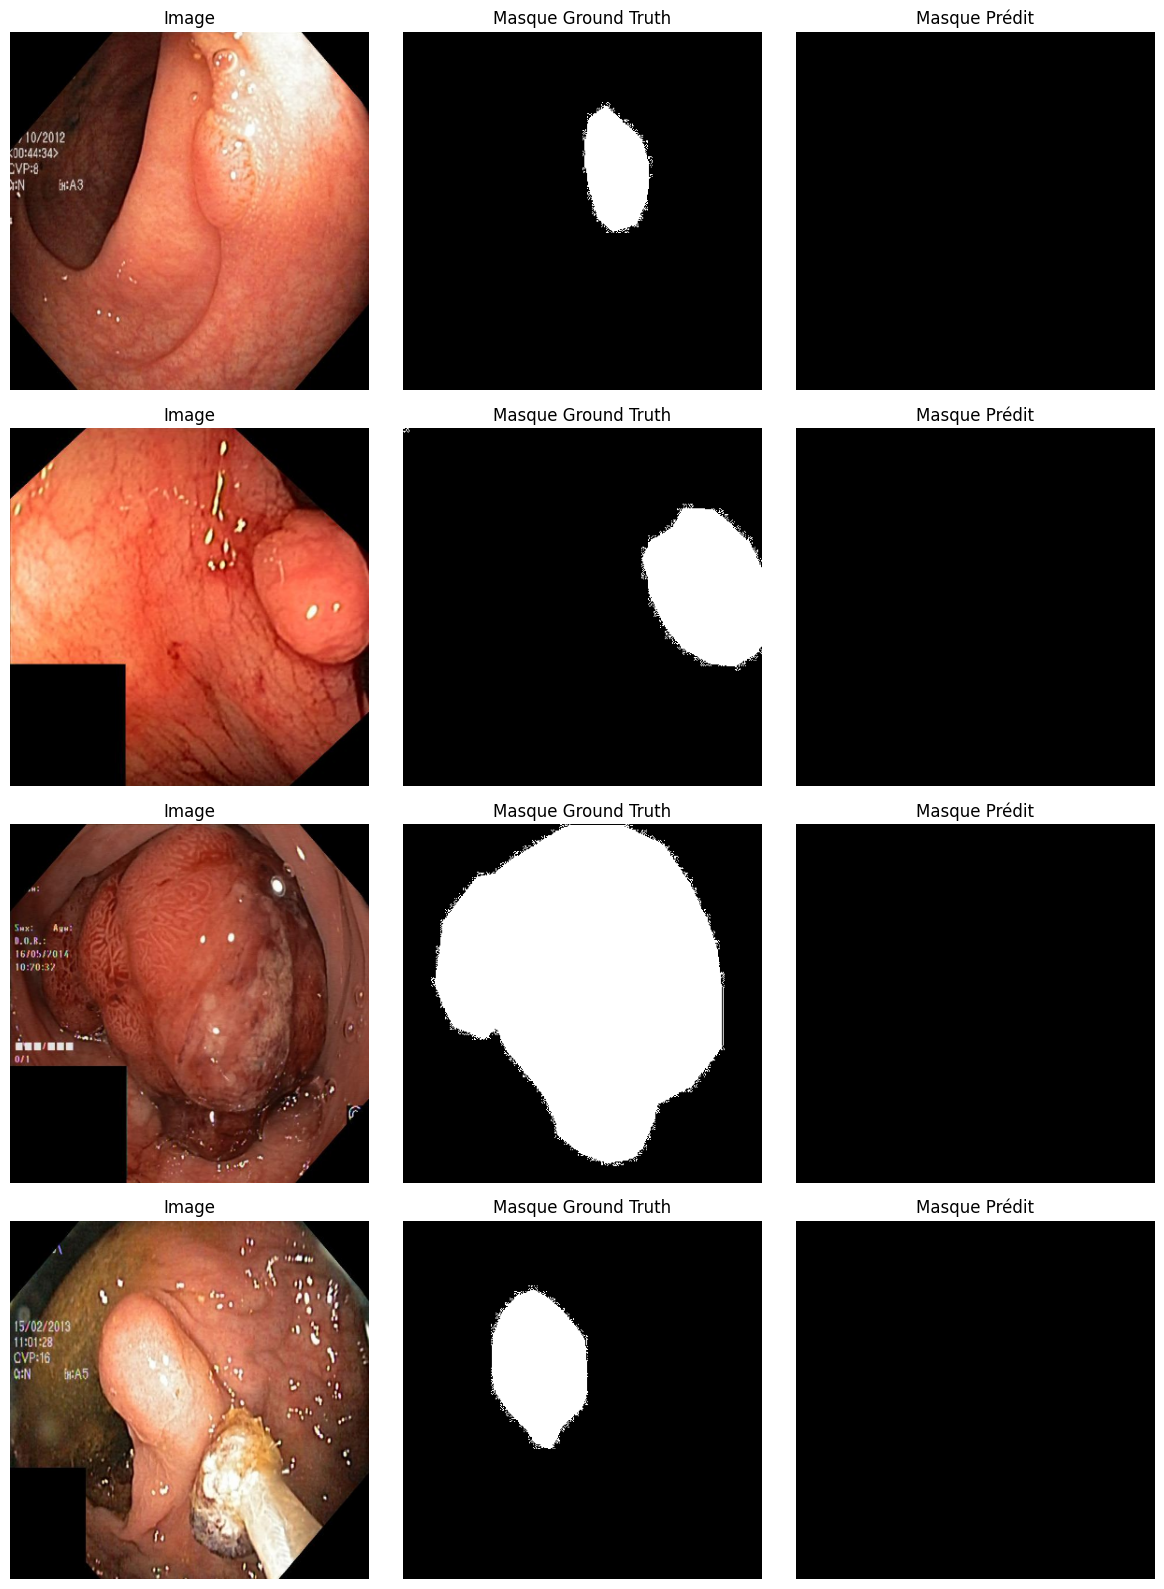

In [20]:
num_examples = 4
test_subset = Subset(test_dataset, range(num_examples))
test_loader_viz = DataLoader(test_subset, batch_size=num_examples, shuffle=False)

student_model.eval()  # ou teacher_model.eval()
with torch.no_grad():
    images, masks = next(iter(test_loader_viz))
    images, masks = images.to(device), masks.to(device)
    outputs = student_model(images)  # ou teacher_model(images)

    # Prédictions argmax sur la dimension des classes
    preds = F.softmax(outputs, dim=1).argmax(dim=1).cpu().numpy()

    # Denormalisation supposée : si images normalisées entre [-0.5,0.5]
    images = images.cpu().permute(0, 2, 3, 1).numpy() * 0.5 + 0.5

    masks = masks.cpu().numpy()

fig, axes = plt.subplots(num_examples, 3, figsize=(12, 4 * num_examples))

for i in range(num_examples):
    axes[i, 0].imshow(images[i])
    axes[i, 0].set_title('Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(masks[i], cmap='gray')
    axes[i, 1].set_title('Masque Ground Truth')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(preds[i], cmap='gray')
    axes[i, 2].set_title('Masque Prédit')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
